In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
normal = cv2.imread("raw_captures/normal.jpeg")
low = cv2.imread("raw_captures/lowlight.jpeg")

In [5]:
print(normal.shape)
print(low.shape)

(1599, 1199, 3)
(1599, 1199, 3)


In [6]:
gray_normal = cv2.cvtColor(normal, cv2.COLOR_BGR2GRAY)

gray_low = cv2.cvtColor(low, cv2.COLOR_BGR2GRAY)

In [7]:
orb = cv2.ORB_create(1000)

In [8]:
kp1, des1 = orb.detectAndCompute(gray_normal, None)

kp2, des2 = orb.detectAndCompute(gray_low, None)

In [9]:
print("Keypoints in Normal Image :", len(kp1))
print("Keypoints in Low-light Image :", len(kp2))

Keypoints in Normal Image : 1000
Keypoints in Low-light Image : 1000


In [10]:
img1 = cv2.drawKeypoints(
    normal,
    kp1,
    None,
    color=(0,255,0)
)

img2 = cv2.drawKeypoints(
    low,
    kp2,
    None,
    color=(0,255,0)
)

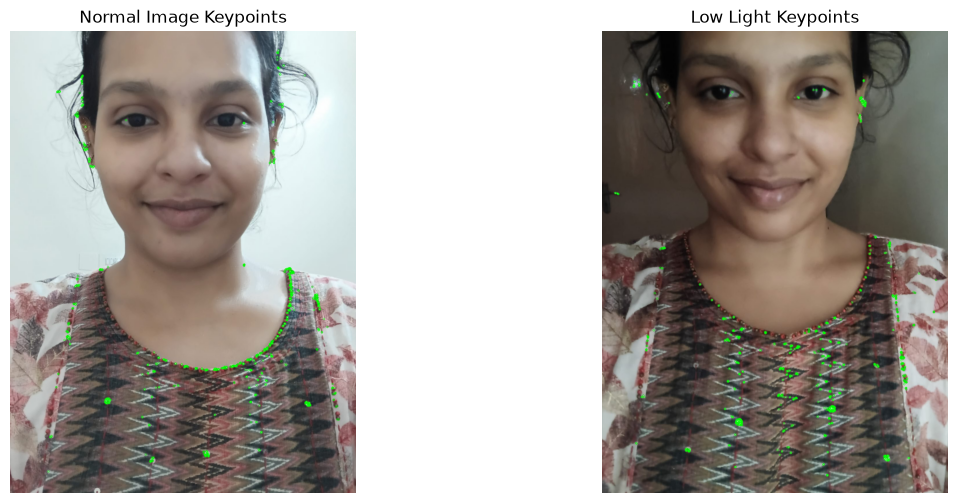

In [11]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1,cv2.COLOR_BGR2RGB))
plt.title("Normal Image Keypoints")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2,cv2.COLOR_BGR2RGB))
plt.title("Low Light Keypoints")
plt.axis("off")

plt.show()

In [12]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

In [13]:
matches = bf.match(des1,des2)

In [14]:
matches = sorted(matches,key=lambda x:x.distance)

In [15]:
    good_matches = matches[:50]

In [16]:
print("Good Matches =",len(good_matches))

Good Matches = 50


In [17]:
matched = cv2.drawMatches(
    normal,
    kp1,
    low,
    kp2,
    good_matches,
    None,
    flags=2
)

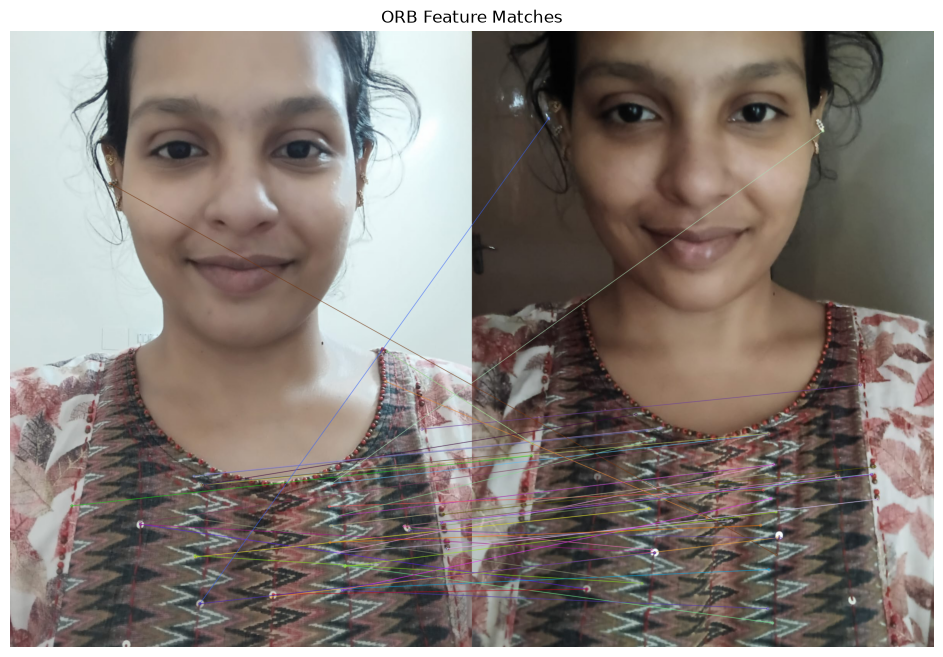

In [18]:
plt.figure(figsize=(20,8))
plt.imshow(cv2.cvtColor(matched,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("ORB Feature Matches")
plt.show()

In [19]:
src_pts = np.float32(
    [kp1[m.queryIdx].pt for m in good_matches]
).reshape(-1,1,2)

dst_pts = np.float32(
    [kp2[m.trainIdx].pt for m in good_matches]
).reshape(-1,1,2)

In [20]:
H, mask = cv2.findHomography(
    dst_pts,
    src_pts,
    cv2.RANSAC,
    5.0
)

In [21]:
height,width = normal.shape[:2]

In [22]:
aligned = cv2.warpPerspective(
    low,
    H,
    (width,height)
)

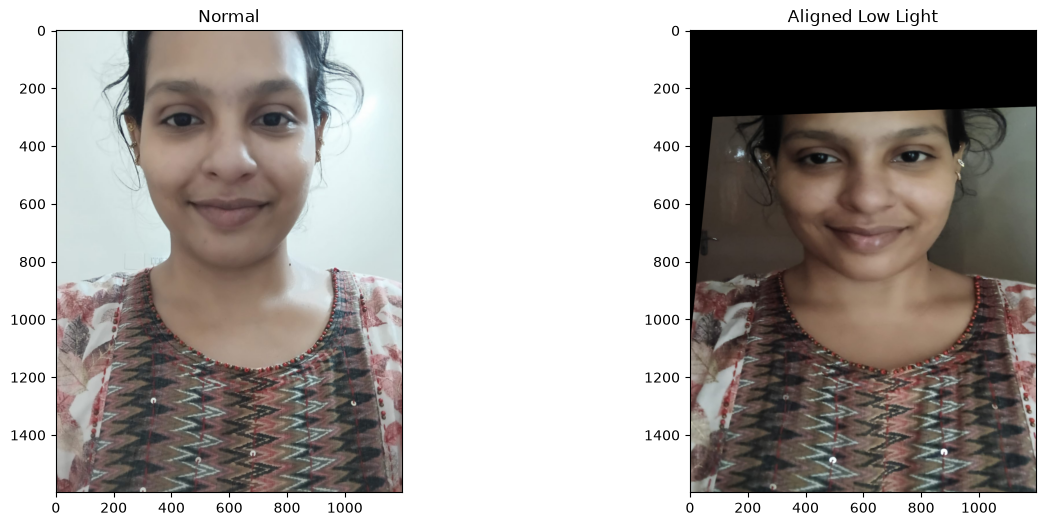

In [23]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(normal,cv2.COLOR_BGR2RGB))
plt.title("Normal")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(aligned,cv2.COLOR_BGR2RGB))
plt.title("Aligned Low Light")

plt.show()

In [24]:
blend1 = cv2.addWeighted(
    normal,
    0.5,
    aligned,
    0.5,
    0
)

In [25]:
blend2 = cv2.addWeighted(
    normal,
    0.7,
    aligned,
    0.3,
    0
)

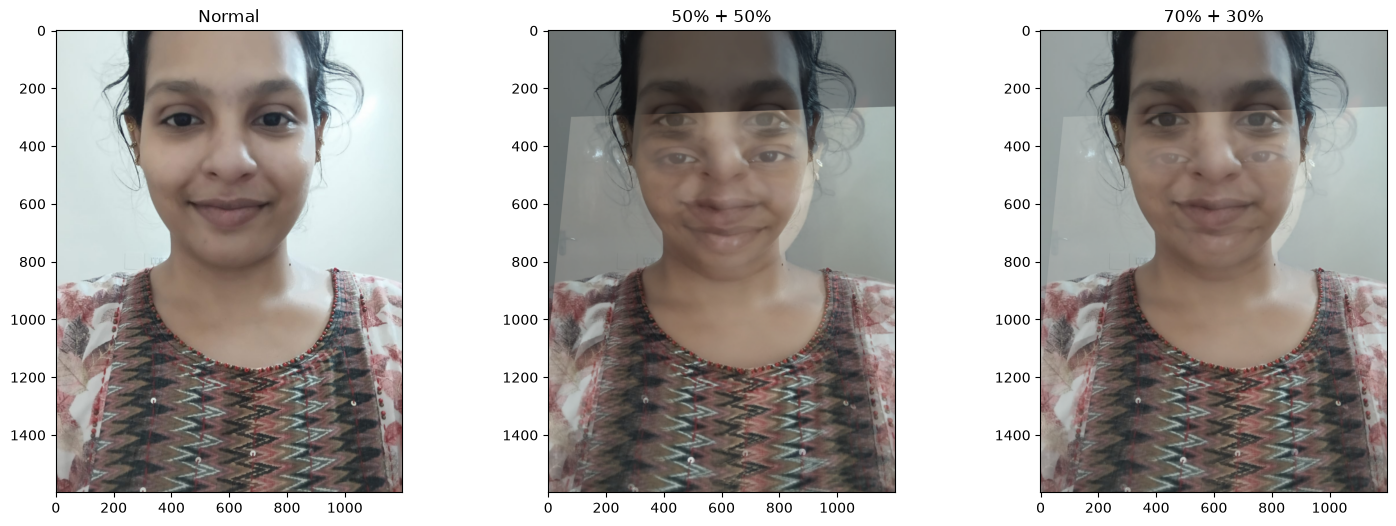

In [26]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(normal,cv2.COLOR_BGR2RGB))
plt.title("Normal")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(blend1,cv2.COLOR_BGR2RGB))
plt.title("50% + 50%")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(blend2,cv2.COLOR_BGR2RGB))
plt.title("70% + 30%")

plt.show()

In [27]:
print("Total Good Matches:",len(good_matches))

Total Good Matches: 50


Observation
ORB detected feature points from both the normal-light and low-light images. Using a Brute-Force matcher, the best feature matches were selected. A homography was estimated using RANSAC, and the low-light image was aligned with the normal-light image using cv2.warpPerspective(). Finally, the aligned images were blended using two different weight combinations (50:50 and 70:30). Since both images show the same subject with only lighting differences and little movement, the homography aligned the images reasonably well. Small differences in facial expression or camera position may cause slight misalignment around the face or hair.